## **Importing Libraries**

In [ ]:
# Preprocessing
import os 
import time
import numpy as np
import pandas as pd
from PIL import Image
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Rendering plotly figures
import plotly.io as pio
pio.renderers.default = "png"

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score ,confusion_matrix

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers , models
from tensorflow.keras.applications import ResNet50 , EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input

In [3]:
import warnings
warnings.filterwarnings("ignore")

## **Global Variables**

In [4]:
path = "/kaggle/input/datasets/salmansajid05/oral-diseases"
classes = {
    "Calculus": "/kaggle/input/datasets/salmansajid05/oral-diseases/Calculus/Calculus",
    "Caries": "/kaggle/input/datasets/salmansajid05/oral-diseases/Data caries/Data caries/caries orignal data set/done",
    "Gingivitis": "/kaggle/input/datasets/salmansajid05/oral-diseases/Gingivitis/Gingivitis",
    "Mouth Ulcer": "/kaggle/input/datasets/salmansajid05/oral-diseases/Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset",
    "Tooth Discoloration": "/kaggle/input/datasets/salmansajid05/oral-diseases/Tooth Discoloration/Tooth Discoloration /tooth discoloration original dataset/tooth discoloration original dataset",
    "Hypodontia": "/kaggle/input/datasets/salmansajid05/oral-diseases/hypodontia/hypodontia"
}
counts = {}
sizes = []
data = []
img_size = (224, 224)    
batch_size = 32
Autotune = tf.data.AUTOTUNE

## **Data Exploration**

In [5]:
for cls, path in classes.items():
    num_imgs = [n for n in os.listdir(os.path.join(path)) if n.lower().endswith((".jpeg", ".jpg", ".png"))]
    counts[cls] = len(num_imgs)

    for s in num_imgs:
        with Image.open(os.path.join(path, s)) as i:
            sizes.append(i.size)


print("Classes Distribution:\n")
for c , n in counts.items():
    print(f"{c} : {n}")            

Classes Distribution:

Calculus : 1296
Caries : 219
Gingivitis : 2349
Mouth Ulcer : 265
Tooth Discoloration : 183
Hypodontia : 1251


In [6]:
for s in sorted(set(sizes)):
    print(s)

(121, 77)
(123, 78)
(123, 91)
(124, 78)
(126, 83)
(135, 72)
(149, 81)
(150, 175)
(151, 33)
(153, 55)
(158, 60)
(164, 115)
(168, 299)
(168, 300)
(171, 65)
(172, 66)
(173, 291)
(175, 59)
(175, 116)
(175, 117)
(176, 117)
(177, 108)
(177, 121)
(178, 74)
(180, 58)
(181, 120)
(183, 115)
(183, 275)
(185, 61)
(185, 273)
(187, 124)
(189, 121)
(191, 68)
(191, 130)
(193, 261)
(194, 75)
(194, 127)
(194, 259)
(197, 256)
(199, 123)
(200, 150)
(200, 252)
(201, 251)
(202, 64)
(202, 88)
(203, 78)
(206, 125)
(208, 120)
(209, 62)
(211, 78)
(212, 238)
(213, 199)
(213, 237)
(214, 87)
(214, 235)
(215, 147)
(215, 235)
(216, 180)
(217, 89)
(219, 230)
(220, 149)
(221, 228)
(222, 227)
(224, 63)
(224, 95)
(225, 151)
(225, 225)
(227, 69)
(227, 222)
(228, 146)
(228, 221)
(230, 100)
(231, 218)
(232, 139)
(232, 218)
(233, 216)
(234, 181)
(235, 214)
(236, 214)
(239, 211)
(240, 160)
(240, 180)
(241, 209)
(242, 165)
(242, 208)
(243, 82)
(243, 207)
(244, 206)
(245, 206)
(246, 86)
(246, 205)
(247, 204)
(248, 164)
(248, 2

In [7]:
for cls, path in classes.items():
    for i in os.listdir(os.path.join(path)):
        if i.lower().endswith((".jpeg", ".jpg", ".png")):
           data.append({
               "FilePath" : str(os.path.join(path, i)),
               "Label" : cls
            })

df = pd.DataFrame(data)
df.sample(5)

,FilePath,Label
2462,/kaggle/input/datasets/salmansajid05/oral-dise...,Gingivitis
3428,/kaggle/input/datasets/salmansajid05/oral-dise...,Gingivitis
3771,/kaggle/input/datasets/salmansajid05/oral-dise...,Gingivitis
4077,/kaggle/input/datasets/salmansajid05/oral-dise...,Mouth Ulcer
2926,/kaggle/input/datasets/salmansajid05/oral-dise...,Gingivitis


In [8]:
df.shape

(5563, 2)

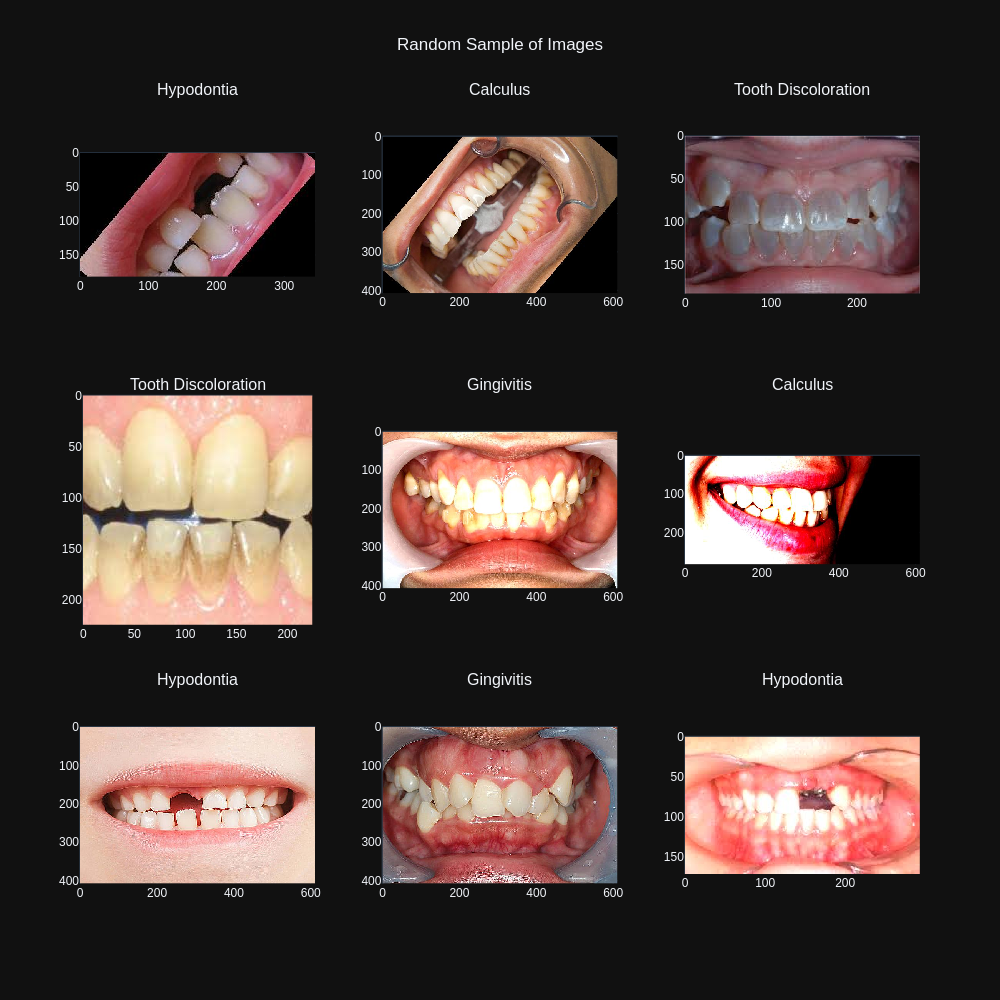

In [9]:
sample = df.sample(9).reset_index(drop=True)
fig = make_subplots(
    rows=3,
    cols=3,
    subplot_titles=sample["Label"].tolist(),
    horizontal_spacing=0.08,
    vertical_spacing=0.08
)
rows, cols = 1,1
for i, row in sample.iterrows():
    img = Image.open(row["FilePath"])

    fig.add_trace(
        go.Image(z=img),
        row= rows,
        col= cols
    )
    cols += 1
    if cols > 3:
        rows += 1
        cols = 1

fig.update_layout(
    title="Random Sample of Images",
    title_x= 0.5,
    template="plotly_dark",
    width=1000,
    height=1000,
)

fig.show()

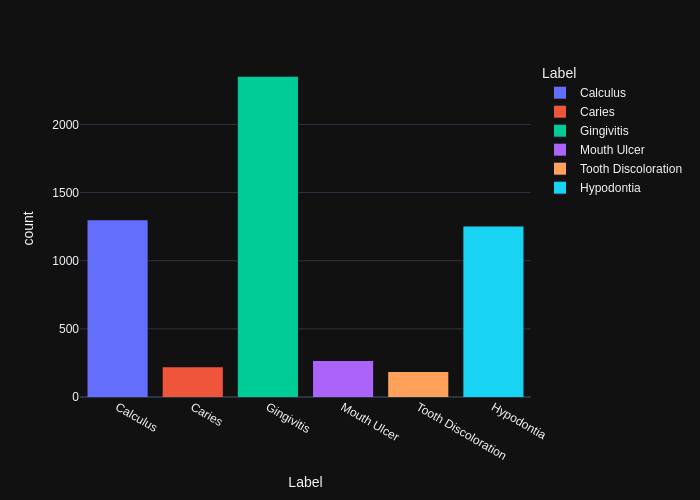

In [10]:
fig1 = px.histogram(df,
                    x="Label",
                    color="Label",
                    template="plotly_dark").show()

## **Preprocessing**

### **Splitting**

In [11]:
train_df, v_t = train_test_split(df,
                                    test_size=0.30,
                                    stratify=df["Label"],
                                    random_state=42)

In [12]:
val_df, test_df = train_test_split(v_t,
                                   test_size=0.15,
                                   stratify=v_t["Label"],
                                   random_state=42)

### **Data Augmentation**

In [13]:
le = LabelEncoder()

train_df["Label"] = le.fit_transform(train_df["Label"])
val_df["Label"] = le.transform(val_df["Label"])
test_df["Label"] = le.transform(test_df["Label"])

In [14]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
    return image , label


In [15]:
def make_img_ds(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            df["FilePath"].values,
            df["Label"].values
        )
    )

    if shuffle:
        ds = ds.shuffle(len(df))

    ds = ds.map(load_image, num_parallel_calls=Autotune)
    ds = ds.batch(batch_size)
    ds = ds.cache().prefetch(buffer_size=Autotune)

    return ds 

In [ ]:
train_ds = make_img_ds(train_df, shuffle=True)
val_ds = make_img_ds(val_df)
test_ds = make_img_ds(test_df)

In [17]:
d_a = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name= "augmentation")

In [18]:
train_ds = train_ds.map(lambda x,y : (d_a(x, training= True), y),
                        num_parallel_calls=Autotune
)

## **Custom CNN Model** 

In [19]:
def training(model, name, train= train_ds, val= val_ds, epochs= 200):
    print(f"Training {name}...")
    
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
             tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)]

    cp = tf.keras.callbacks.ModelCheckpoint(f"{name}.keras", monitor="val_accuracy", save_best_only=True, verbose=1)

    start = time.time()

    hist = model.fit(train, validation_data=val, epochs=epochs, callbacks=[callbacks, cp])

    train_time = time.time() - start

    print(f"Training Time: {train_time:0.3f}s.")
  
    return hist 

In [20]:
cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(*img_size, 3)),

    layers.Rescaling(1./255),
        
    layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding= "same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
        
    layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding= "same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
        
    layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding= "same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
        
    layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding= "same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
        
    layers.GlobalAveragePooling2D(),
        
    layers.Dropout(0.5),
        
    layers.Dense(6, activation="softmax")])

cnn.compile(
        optimizer= tf.keras.optimizers.Adam(1e-4),
        loss= "sparse_categorical_crossentropy",
        metrics= ["accuracy"]
    )


cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,878 (1.49 MB)

 Trainable params: 390,918 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
CNN = training(cnn, "Custom_CNN")

Training Custom_CNN...
Epoch 1/200
  2/122 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.2344 - loss: 2.4018 

I0000 00:00:1784080646.496003     279 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.4380 - loss: 1.5506
Epoch 1: val_accuracy improved from None to 0.04725, saving model to Custom_CNN.keras

Epoch 1: finished saving model to Custom_CNN.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 46s 290ms/step - accuracy: 0.4954 - loss: 1.3761 - val_accuracy: 0.0472 - val_loss: 3.1271 - learning_rate: 1.0000e-04
Epoch 2/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5569 - loss: 1.1842
Epoch 2: val_accuracy did not improve from 0.04725
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.5724 - loss: 1.1559 - val_accuracy: 0.0472 - val_loss: 5.0476 - learning_rate: 1.0000e-04
Epoch 3/200
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5794 - loss: 1.0937
Epoch 3: val_accuracy improved from 0.04725 to 0.19464, saving model to Custom_CNN.keras

Epoch 3: finished saving model to Custom_CNN.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.5909 - loss: 1.0685 - val_accuracy: 0.1946 - val_loss: 4.3552

## **ResNet**

In [22]:
res = ResNet50(include_top= False, weights= "imagenet", input_shape=(*img_size, 3))
res.trainable = False

res_model = tf.keras.Sequential([
    tf.keras.Input(shape=(*img_size, 3)),
    
    layers.Lambda(preprocess_input), 
    
    res,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.5),
    
    layers.Dense(6, activation="softmax")])

res_model.compile(
        optimizer= tf.keras.optimizers.Adam(1e-4),
        loss= "sparse_categorical_crossentropy",
        metrics= ["accuracy"]
    )

res_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
ResNet = training(res_model, "ResNet")

Training ResNet...
Epoch 1/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.3502 - loss: 2.0271
Epoch 1: val_accuracy improved from None to 0.50846, saving model to ResNet.keras

Epoch 1: finished saving model to ResNet.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 53s 332ms/step - accuracy: 0.3885 - loss: 1.8641 - val_accuracy: 0.5085 - val_loss: 1.2915 - learning_rate: 1.0000e-04
Epoch 2/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4495 - loss: 1.6320
Epoch 2: val_accuracy improved from 0.50846 to 0.59379, saving model to ResNet.keras

Epoch 2: finished saving model to ResNet.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 29s 229ms/step - accuracy: 0.4625 - loss: 1.5687 - val_accuracy: 0.5938 - val_loss: 1.0759 - learning_rate: 1.0000e-04
Epoch 3/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.5125 - loss: 1.3757
Epoch 3: val_accuracy improved from 0.59379 to 0.62341, saving model to ResNet.keras

Epoch 3: finished saving model to ResNet.keras
122/122 ━━━━━━━━━━━━━━

## **EfficientNetB0**

In [24]:
eff = EfficientNetB0(include_top= False, weights= "imagenet", input_shape=(*img_size, 3))
eff.trainable = False

eff_model = tf.keras.Sequential([
    tf.keras.Input(shape=(*img_size, 3)),
    
    eff,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.5),
    
    layers.Dense(6, activation="softmax")])

eff_model.compile(
        optimizer= tf.keras.optimizers.Adam(1e-4),
        loss= "sparse_categorical_crossentropy",
        metrics= ["accuracy"]
    )

eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
EfficientNet = training(eff_model, "EfficientNetB0")

Training EfficientNetB0...
Epoch 1/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.2140 - loss: 1.8843
Epoch 1: val_accuracy improved from None to 0.43794, saving model to EfficientNetB0.keras

Epoch 1: finished saving model to EfficientNetB0.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 80s 450ms/step - accuracy: 0.2933 - loss: 1.6911 - val_accuracy: 0.4379 - val_loss: 1.3591 - learning_rate: 1.0000e-04
Epoch 2/200
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.4379 - loss: 1.4123
Epoch 2: val_accuracy improved from 0.43794 to 0.56770, saving model to EfficientNetB0.keras

Epoch 2: finished saving model to EfficientNetB0.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 25s 196ms/step - accuracy: 0.4661 - loss: 1.3650 - val_accuracy: 0.5677 - val_loss: 1.1754 - learning_rate: 1.0000e-04
Epoch 3/200
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5273 - loss: 1.2667
Epoch 3: val_accuracy improved from 0.56770 to 0.59379, saving model to EfficientNetB0.keras

Epoch 3: finished sav

## **Evaluation**

In [30]:
def eval(model, name, history, test= test_ds, classes= list(classes.keys())):
    
    fig2 = make_subplots(rows=2, cols=1,subplot_titles=["Train_Val Accuracy", "Train_Val Loss"])

    fig2.add_trace(
        go.Scatter(
        y= history.history["accuracy"],
        name= "Training Accuracy",
        mode= "lines",
        line= dict(width=3, color="green")),
        row= 1, col= 1)

    fig2.add_trace(
        go.Scatter(
        y= history.history["val_accuracy"],
        name= "Validation Accuracy",
        mode= "lines",
        line= dict(width=3, color="red")),
        row= 1, col= 1)

    fig2.add_trace(
        go.Scatter(
        y= history.history["loss"],
        name= "Training Loss",
        mode= "lines",
        line= dict(width=3, color="orange")),
        row= 2, col= 1)

    fig2.add_trace(
        go.Scatter(
        y= history.history["val_loss"],
        name= "Validation Loss",
        mode= "lines",
        line= dict(width=3, color="blue")),
        row= 2, col= 1)

    fig2.update_layout(
        width=1000,
        height=1000,
        template="plotly_dark")

    fig2.show()

    print("=" * 200, "\n")

    y_test, y_pred = [], []
    for x, y in test:
        preds = model.predict(x, verbose= 0)
        y_test.extend(y.numpy())
        y_pred.extend(np.argmax(preds, axis= 1))

    t_loss, t_acc = model.evaluate(test) 

    print(f"Test Loss: {t_loss:.4f}")
    print(f"Test Accuracy: {t_acc:.4f}\n")

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{name} Accuracy:  {acc:0.3f}")
    print(f"{name} F1-Score:  {f1:0.3f} \n")

    print(f"{name} Classification Report: \n{classification_report(y_test, y_pred, target_names= classes)}\n")

    cm = confusion_matrix(y_test, y_pred)
    fig3 = px.imshow(cm,
                    x= classes,
                    y= classes,
                    zmin= cm.min(),
                    zmax= cm.max(),
                    title= "Confusion Matrix",
                    aspect= "auto",
                    text_auto= True,
                    color_continuous_scale= "Blues", 
                    template= "plotly_dark").update_layout(width= 1000,
                                                          height= 1000,
                                                          title_x= 0.5).show()
    
    return {
        "Model" : name,
        "Accuracy" : acc,
        "F1-Score" : f1
    }

In [32]:
models = {
    "CNN": cnn,
    "ResNet50": res_model,
    "EfficientNetB0": eff_model
}

hist = {
    "CNN" : CNN,
    "ResNet50" : ResNet,
    "EfficientNetB0" : EfficientNet
}

Evaluating CNN...



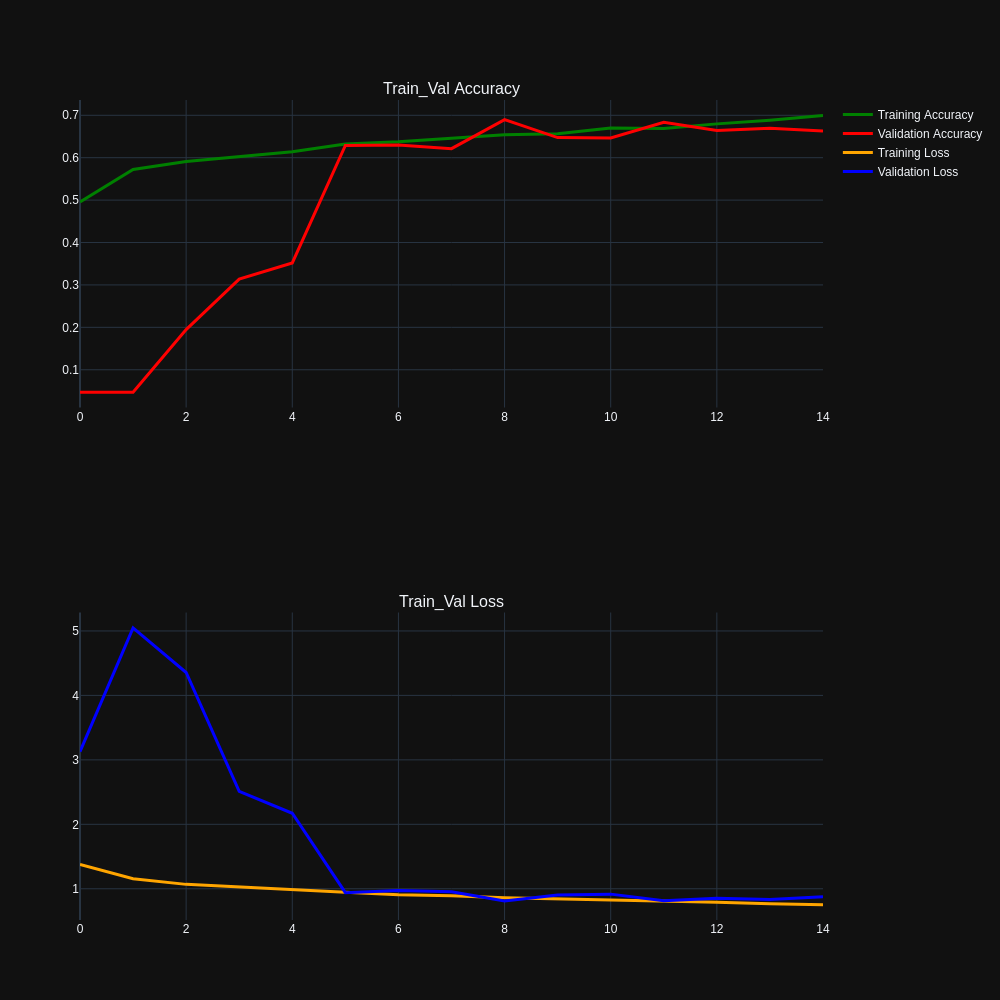


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7012 - loss: 0.8087
Test Loss: 0.8087
Test Accuracy: 0.7012

CNN Accuracy:  0.701
CNN F1-Score:  0.671 

CNN Classification Report: 
                     precision    recall  f1-score   support

           Calculus       0.64      0.49      0.56        59
             Caries       1.00      0.10      0.18        10
         Gingivitis       0.67      0.86      0.76       106
        Mouth Ulcer       0.78      0.88      0.82        56
Tooth Discoloration       0.86      0.50      0.63        12
         Hypodontia       0.00      0.00      0.00         8

           accuracy                           0.70       251
          macro avg       0.66      0.47      0.49       251
       weighted avg       0.69      0.70      0.67       251




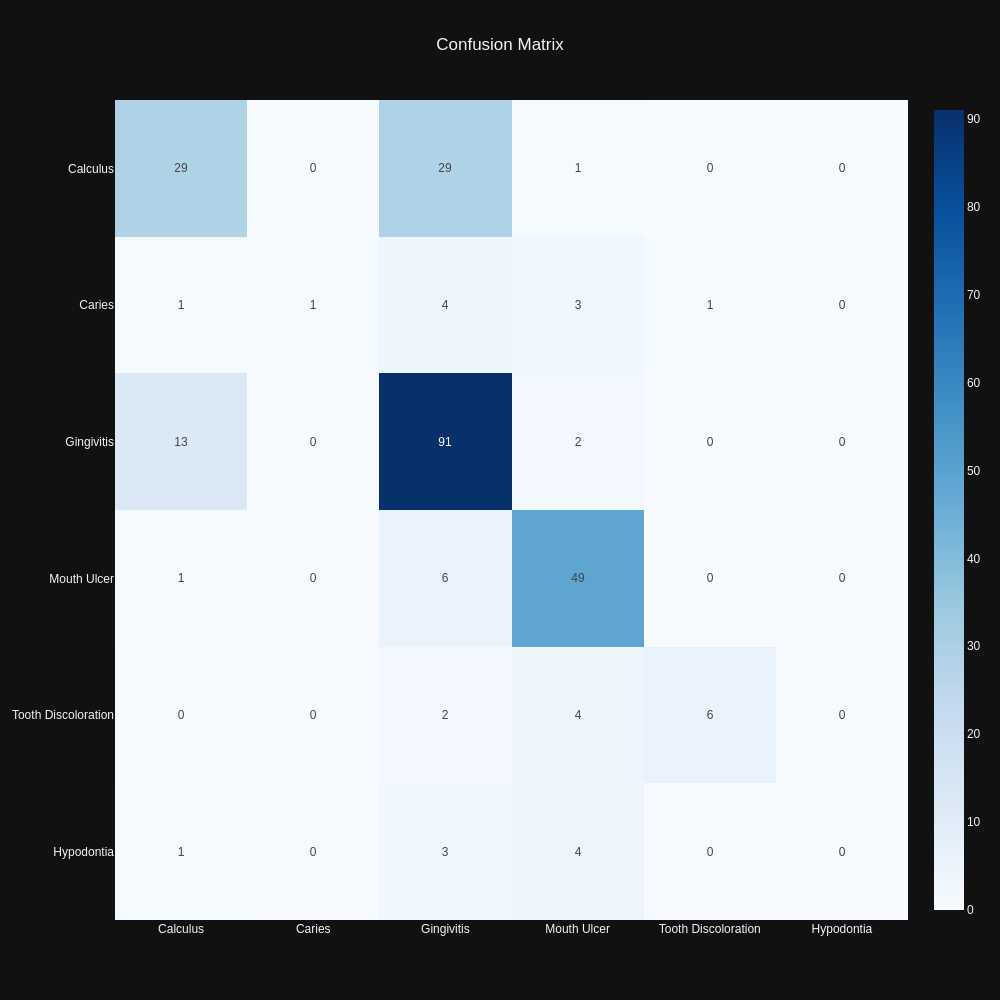


Evaluating ResNet50...



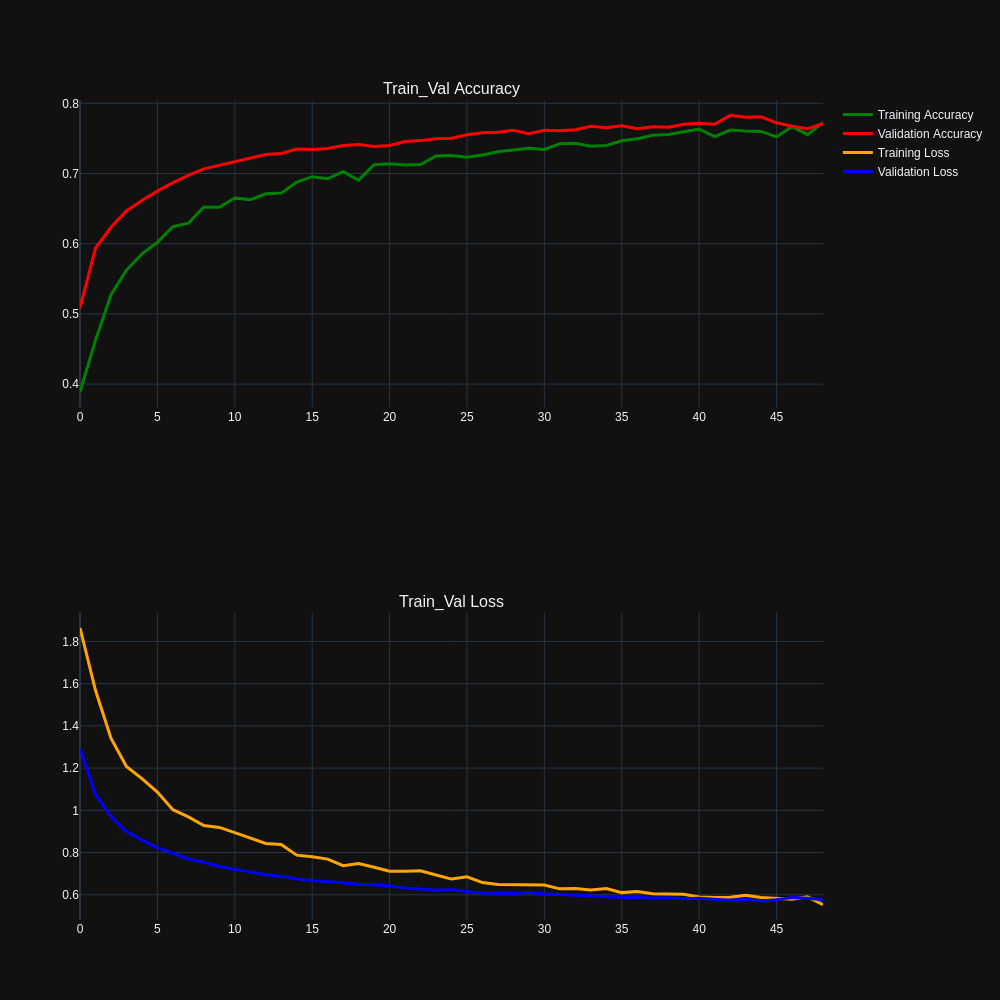


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7729 - loss: 0.5628
Test Loss: 0.5628
Test Accuracy: 0.7729

ResNet50 Accuracy:  0.773
ResNet50 F1-Score:  0.769 

ResNet50 Classification Report: 
                     precision    recall  f1-score   support

           Calculus       0.69      0.69      0.69        59
             Caries       0.71      0.50      0.59        10
         Gingivitis       0.78      0.81      0.80       106
        Mouth Ulcer       0.84      0.88      0.86        56
Tooth Discoloration       0.83      0.83      0.83        12
         Hypodontia       0.60      0.38      0.46         8

           accuracy                           0.77       251
          macro avg       0.74      0.68      0.71       251
       weighted avg       0.77      0.77      0.77       251




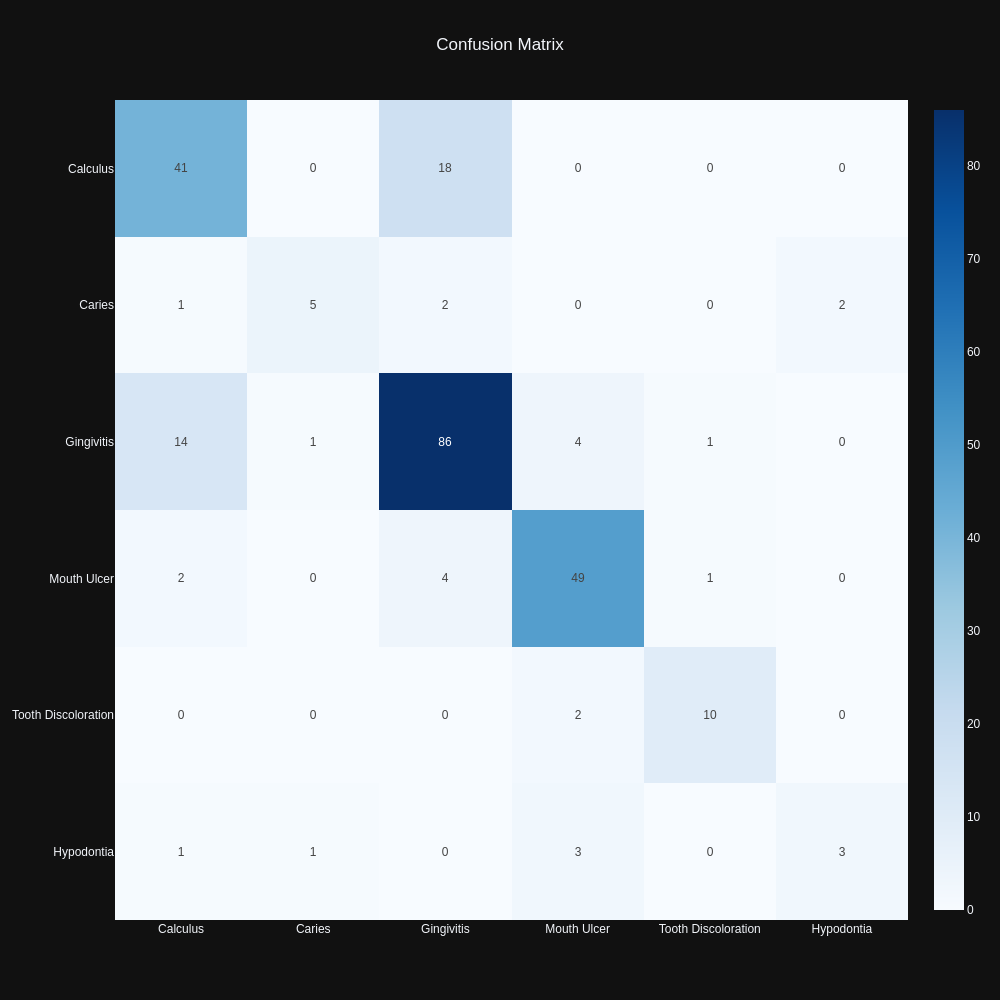


Evaluating EfficientNetB0...



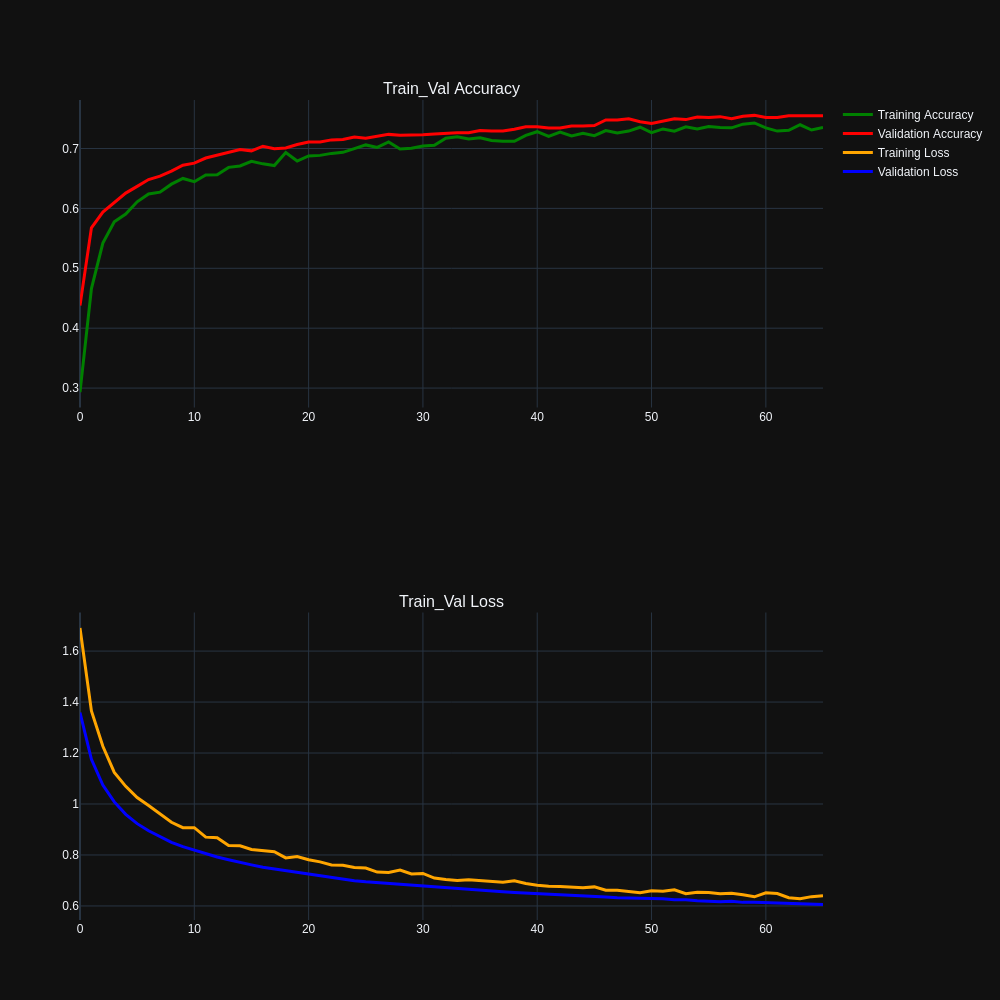


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 619ms/step - accuracy: 0.7649 - loss: 0.5996
Test Loss: 0.5996
Test Accuracy: 0.7649

EfficientNetB0 Accuracy:  0.765
EfficientNetB0 F1-Score:  0.753 

EfficientNetB0 Classification Report: 
                     precision    recall  f1-score   support

           Calculus       0.76      0.47      0.58        59
             Caries       0.62      0.50      0.56        10
         Gingivitis       0.71      0.91      0.79       106
        Mouth Ulcer       0.93      0.89      0.91        56
Tooth Discoloration       0.77      0.83      0.80        12
         Hypodontia       1.00      0.38      0.55         8

           accuracy                           0.76       251
          macro avg       0.80      0.66      0.70       251
       weighted avg       0.78      0.76      0.75       251




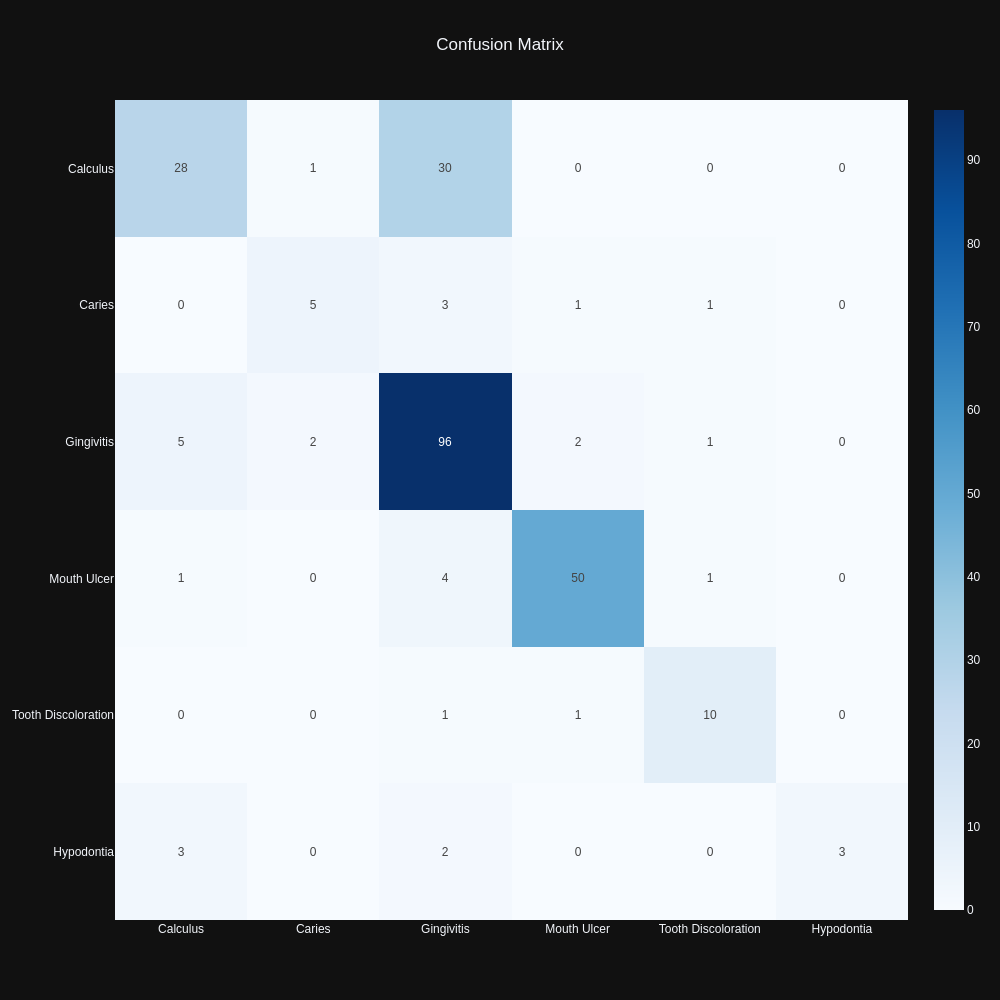

In [34]:
results= []

for name, model in models.items():
    print(f"Evaluating {name}...\n")

    result = eval(model, name, hist[name])

    print("=" * 200, '\n')

    results.append(result)

## **Comparing Models for Final Selection**

In [37]:
train_times = {
    "CNN": 378.244,
    "ResNet50": 1415.846,
    "EfficientNetB0": 1649.205
}

results_df = pd.DataFrame(results)

results_df["Training Time (s)"] = results_df["Model"].map(train_times)

In [38]:
results_df

,Model,Accuracy,F1-Score,Training Time (s)
0,CNN,0.701195,0.671189,378.244
1,ResNet50,0.772908,0.769412,1415.846
2,EfficientNetB0,0.764940,0.752765,1649.205


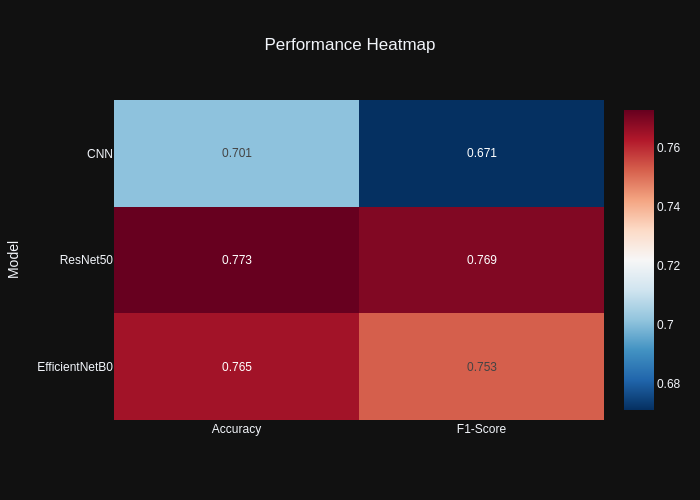

In [49]:
fig3 = px.imshow(
    results_df.set_index("Model")[["Accuracy",  "F1-Score"]],
    text_auto=".3f",
    color_continuous_scale="RdBu_r",
    title= "Performance Heatmap",
    aspect="auto").update_layout(
    template="plotly_dark",
    title_x= 0.5).show()

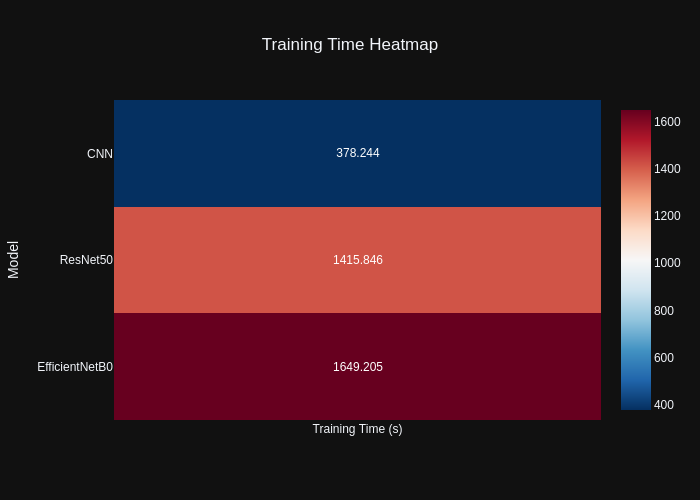

In [52]:
fig4 = px.imshow(
    results_df.set_index("Model")[["Training Time (s)"]],
    text_auto=".3f",
    color_continuous_scale="RdBu_r",
    title= "Training Time Heatmap",
    aspect="auto").update_layout(
    template="plotly_dark",
    title_x= 0.5).show()

## **Model Performance Summary**

**Three deep learning models were evaluated for oral disease classification: a Custom CNN, ResNet50, and EfficientNetB0.**

**The Custom CNN achieved an accuracy of 70.12% with an F1-score of 0.671 after 378.24 seconds of training.**

**EfficientNetB0 achieved 76.49% accuracy with an F1-score of 0.753, but required the longest training time (1649.21 seconds).**

**ResNet50 achieved the best overall performance, reaching 77.29% accuracy and an F1-score of 0.769 in 1415.85 seconds.**

**Based on the evaluation metrics, ResNet50 provided the best balance between predictive performance and training efficiency, making it the preferred model for Deployment.**